In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn import metrics
import matplotlib.pyplot as plt

In [2]:
col_names = ['pregnant','glucose','bp','skin','insulin','bmi','pedigree','age','label']
pima = pd.read_csv('diabetes_pima_indian.csv',names=col_names,header=None)
print(pima.head(8))

   pregnant  glucose  bp  skin  insulin   bmi  pedigree  age  label
0         6      148  72    35        0  33.6     0.627   50      1
1         1       85  66    29        0  26.6     0.351   31      0
2         8      183  64     0        0  23.3     0.672   32      1
3         1       89  66    23       94  28.1     0.167   21      0
4         0      137  40    35      168  43.1     2.288   33      1
5         5      116  74     0        0  25.6     0.201   30      0
6         3       78  50    32       88  31.0     0.248   26      1
7        10      115   0     0        0  35.3     0.134   29      0


In [3]:
feature_cols = ['pregnant','insulin','bmi','age','glucose','bp','pedigree']
X = pima[feature_cols]
y = pima.label
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
clf = DecisionTreeClassifier(max_depth=6,splitter='best',criterion='entropy')
clf = clf.fit(X_train,y_train)

y_pred = clf.predict(X_test)

In [5]:
print("Accuracy:",metrics.accuracy_score(y_test,y_pred))
print(metrics.classification_report(y_test,y_pred))
print(metrics.confusion_matrix(y_test,y_pred))

Accuracy: 0.7792207792207793
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        99
           1       0.69      0.69      0.69        55

    accuracy                           0.78       154
   macro avg       0.76      0.76      0.76       154
weighted avg       0.78      0.78      0.78       154

[[82 17]
 [17 38]]


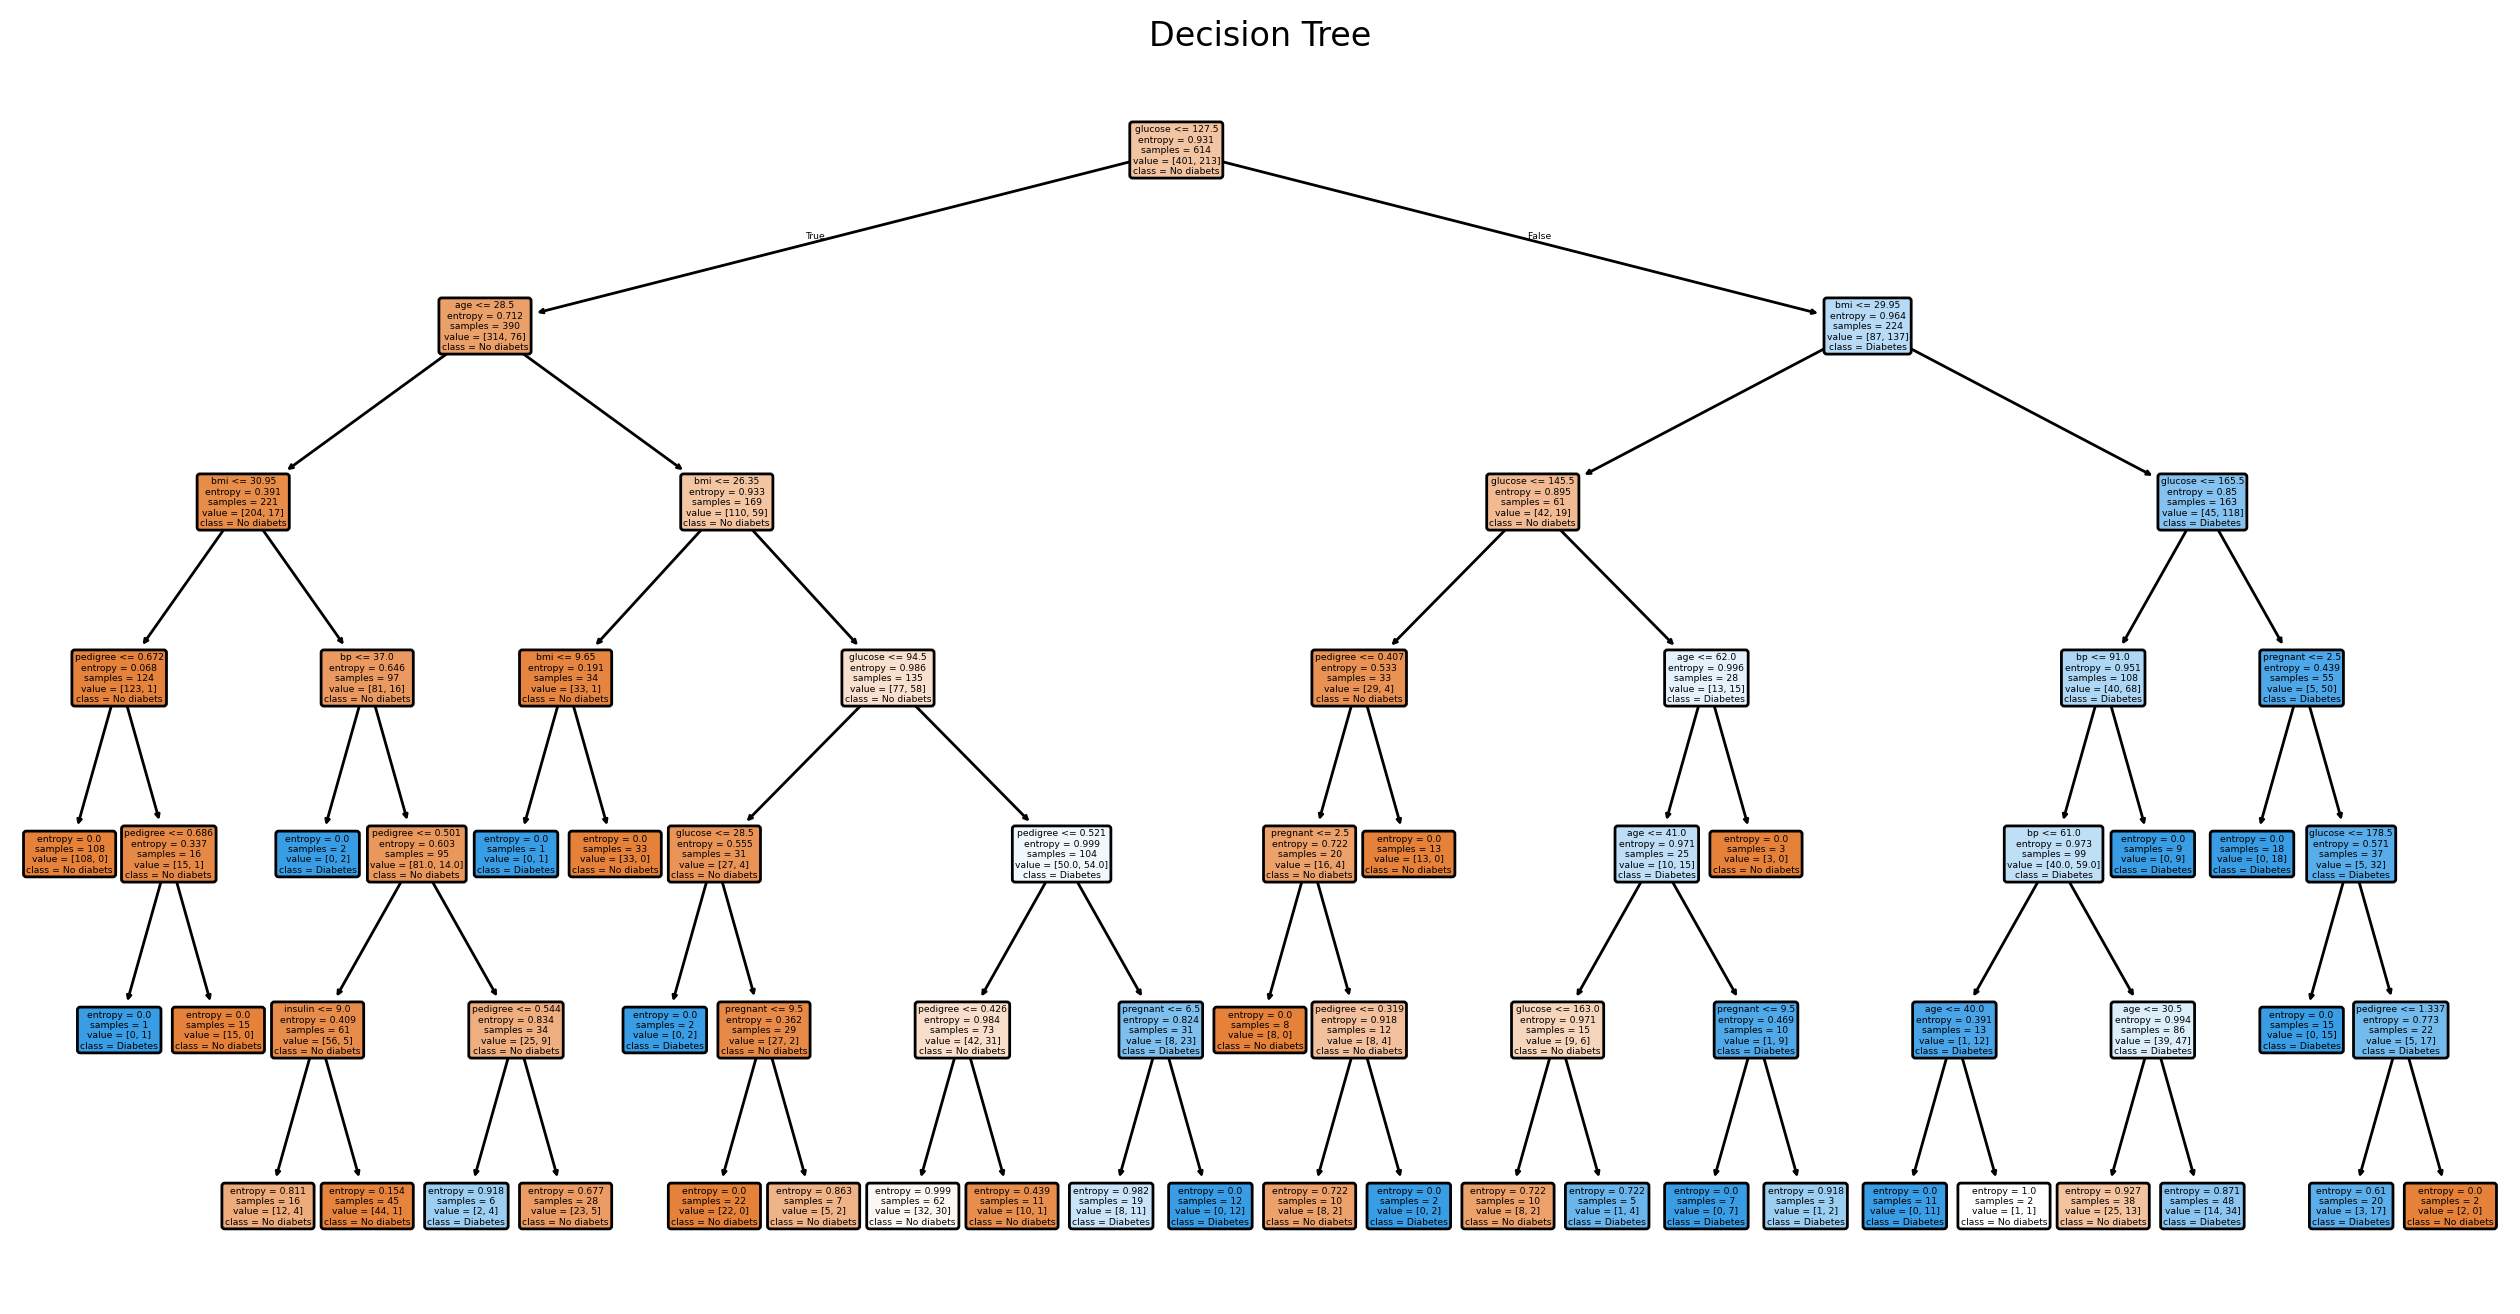

In [7]:

#wykres drzewa decyzyjnego
plt.figure(figsize=(16,8),dpi=200)
plot_tree(clf,
          feature_names=feature_cols,
          class_names = ["No diabets","Diabetes"],
          filled=True,rounded = True)
plt.title("Decision Tree")
plt.savefig("drzewo.png")
plt.show()